# Learning Eulerian dynamics with neural networks

In this practical, we learn a discrete time-evolution operator for the two-dimensional Navier–Stokes equations. The state is represented in an **Eulerian** frame: vorticity is stored at fixed points on a spatial grid rather than by following fluid particles.

Given a vorticity field $\omega_t(x,y)$, the learning task is

$$\mathcal{G}_\theta:\omega_t \mapsto \widehat{\omega}_{t+1}.$$

We compare two parameterizations of $\mathcal{G}_\theta$: a convolutional U-Net and a spatial Transformer.

## Models studied in this practical

### 1. Periodic U-Net

The U-Net uses local convolutions, multiple spatial resolutions, and skip connections. Circular padding incorporates the periodic boundary conditions of the domain. It provides a strong architecture with a useful locality bias for grid-based physical fields.

### 2. Spatial Transformer

The spatial Transformer represents every grid point as a token and applies global self-attention between all tokens. This permits direct long-range communication, but its attention cost grows quadratically with the number of grid points. For the downsampled $32\times32$ grid, attention operates on $N=1024$ tokens.

## Student implementation

The dataset pipeline, U-Net, spatial Transformer, training loops, metrics, and plotting utilities are provided. In Section 6, you must implement the following two functions:

- `rollout_model`: generate a multi-step autoregressive trajectory by repeatedly using each normalized model prediction as the input to the next step;
- `rollout_model_teacher_forcing`: generate one-step predictions across a trajectory while using the corresponding true state as the input at every step.

Both functions must follow the normalization, physical-unit conversion, indexing, and output-shape requirements documented in their docstrings. The supplied evaluation and plotting cells will use your implementations to compare rollout behavior for the U-Net and spatial Transformer.

## Learning objectives

By the end of the practical, you should be able to:

- turn simulated trajectories into supervised one-step training pairs;
- incorporate periodic boundary conditions into a neural architecture;
- distinguish one-step, teacher-forced, and autoregressive evaluation;
- explain why small one-step errors can accumulate during a rollout;
- explain queries, keys, values, and multi-head self-attention;
- compare the one-step accuracy and autoregressive rollout behavior of a U-Net and a spatial Transformer.

## 1. Setup and data

We begin by importing the required libraries, fixing random seeds, and selecting a GPU when one is available.

In [1]:
from pathlib import Path
import random

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import copy
import time

from huggingface_hub import hf_hub_download

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


### Downloading and inspecting the dataset

The dataset is downloaded from the standard PDE benchmark collection and stored locally. We inspect its variables, dimensions, and an example transition before constructing training samples.

> The seed controls the main random-number generators, but exact reproducibility can still depend on hardware and low-level CUDA operations.

In [3]:
DATA_DIR = Path("data/navier_stokes")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_path = hf_hub_download(
    repo_id="kmario23/standard-pde-benchmark",
    repo_type="dataset",
    filename="ns/NavierStokes_V1e-5_N1200_T20.mat",
    local_dir=DATA_DIR,
)

data_path = Path(data_path)

print("Dataset path:")
print(data_path)

print(f"\nFile size: {data_path.stat().st_size / 1024**2:.1f} MB")

ns/NavierStokes_V1e-5_N1200_T20.mat: reconstructing file:   0%|          |  0.00B /  413MB            

ns/NavierStokes_V1e-5_N1200_T20.mat: downloading bytes:           |  0.00B            

Dataset path:
/content/data/navier_stokes/ns/NavierStokes_V1e-5_N1200_T20.mat

File size: 393.8 MB


In [4]:
data = sio.loadmat(data_path)

print("Variables stored in the .mat file:")
print(data.keys())

Variables stored in the .mat file:
dict_keys(['__header__', '__version__', '__globals__', 'a', 'u', 't'])


In [5]:
initial_vorticity = data["a"]   # omega(x, y, 0)
vorticity = data["u"]           # omega(x, y, t_1), ..., omega(x, y, t_20)

print("Initial conditions:", initial_vorticity.shape)
print("Trajectories:      ", vorticity.shape)
print("dtype:             ", vorticity.dtype)

Initial conditions: (1200, 64, 64)
Trajectories:       (1200, 64, 64, 20)
dtype:              float32


In [6]:
n_trajectories, nx, ny, n_timesteps = vorticity.shape

print("Number of trajectories :", n_trajectories)
print("Spatial resolution     :", nx, "x", ny)
print("Number of time steps   :", n_timesteps)

Number of trajectories : 1200
Spatial resolution     : 64 x 64
Number of time steps   : 20


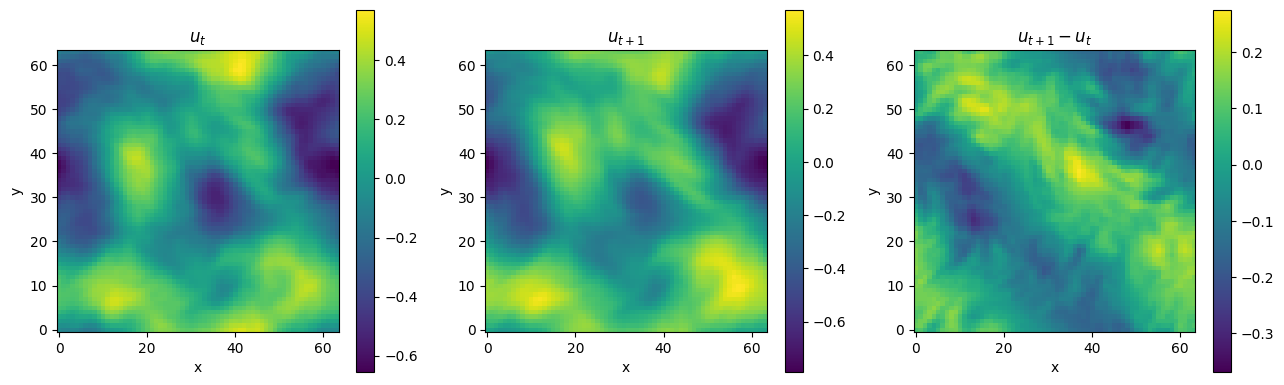

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(vorticity[0,:,:,0], origin="lower")
axes[0].set_title(r"$u_t$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(vorticity[0,:,:,1], origin="lower")
axes[1].set_title(r"$u_{t+1}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

difference = vorticity[0,:,:,1] - vorticity[0,:,:,0]
im2 = axes[2].imshow(difference, origin="lower")
axes[2].set_title(r"$u_{t+1} - u_t$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 2. From trajectories to supervised examples

Each simulation contains an initial condition $\omega_0$ and 20 later states $\omega_1,\ldots,\omega_{20}$. We convert every trajectory into 20 adjacent pairs

$$ (\omega_0,\omega_1), (\omega_1,\omega_2),\ldots,(\omega_{19},\omega_{20}). $$

The split is performed by **trajectory**, not by individual pairs. This prevents states from the same simulation appearing in both training and evaluation data. We also subsample the grid from $64\times64$ to $32\times32$ and compute normalization statistics using training data only.

In [8]:
train_indices = np.arange(0, 900)
val_indices = np.arange(900, 1000)
test_indices = np.arange(1000, 1200)

print("Train trajectories:", len(train_indices))
print("Val trajectories:  ", len(val_indices))
print("Test trajectories: ", len(test_indices))

Train trajectories: 900
Val trajectories:   100
Test trajectories:  200


In [9]:
SPATIAL_STRIDE = 2

train_a = initial_vorticity[train_indices, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

train_u = vorticity[
    train_indices,
    ::SPATIAL_STRIDE,
    ::SPATIAL_STRIDE,
    :
]

n_values = train_a.size + train_u.size

sum_values = (
    train_a.astype(np.float64).sum()
    + train_u.astype(np.float64).sum()
)

sum_squared = (
    np.square(train_a.astype(np.float64)).sum()
    + np.square(train_u.astype(np.float64)).sum()
)

omega_mean = sum_values / n_values
omega_var = sum_squared / n_values - omega_mean**2
omega_std = np.sqrt(omega_var)

print(f"Training mean: {omega_mean:.6f}")
print(f"Training std:  {omega_std:.6f}")

Training mean: 0.000019
Training std:  1.105457


### Dataset and data loaders

The custom PyTorch dataset maps a single integer index to a trajectory and time step. For the first transition the input comes from `a`; later inputs come from the preceding slice of `u`.

A channel dimension is added because PyTorch convolutional layers expect tensors ordered as `[batch, channels, height, width]`.

In [10]:
class NavierStokesOneStepDataset(Dataset):
    """
    Dataset of one-step vorticity transitions:

        omega_t -> omega_{t+1}

    Each trajectory contains:
        omega_0 = initial_vorticity
        omega_1, ..., omega_20 = vorticity[..., 0:20]

    Therefore each trajectory gives 20 transitions.
    """

    def __init__(
        self,
        initial_vorticity,
        vorticity,
        trajectory_indices,
        mean,
        std,
        spatial_stride=1,
    ):
        self.initial_vorticity = initial_vorticity
        self.vorticity = vorticity
        self.trajectory_indices = np.asarray(trajectory_indices)

        self.mean = mean
        self.std = std
        self.spatial_stride = spatial_stride

        self.n_transitions = vorticity.shape[-1]  # 20


    def __len__(self):
        return len(self.trajectory_indices) * self.n_transitions


    def __getitem__(self, idx):

        # Which trajectory?
        trajectory_position = idx // self.n_transitions

        # Which transition inside that trajectory?
        t = idx % self.n_transitions

        trajectory_idx = self.trajectory_indices[trajectory_position]

        # -------------------------------------------------
        # Construct omega_t
        # -------------------------------------------------

        if t == 0:
            # omega_0 comes from "a"
            x = self.initial_vorticity[
                trajectory_idx,
                ::self.spatial_stride,
                ::self.spatial_stride,
            ]

        else:
            # omega_t is stored at u[..., t-1]
            x = self.vorticity[
                trajectory_idx,
                ::self.spatial_stride,
                ::self.spatial_stride,
                t - 1,
            ]

        # -------------------------------------------------
        # omega_{t+1}
        # -------------------------------------------------

        y = self.vorticity[
            trajectory_idx,
            ::self.spatial_stride,
            ::self.spatial_stride,
            t,
        ]

        # Convert to float32
        x = x.astype(np.float32)
        y = y.astype(np.float32)

        # Normalize
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        # Convert to tensors
        x = torch.from_numpy(x)
        y = torch.from_numpy(y)

        # Add channel dimension:
        #
        # [H, W] -> [1, H, W]
        #
        x = x.unsqueeze(0)
        y = y.unsqueeze(0)

        return x, y

In [11]:
train_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=train_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

val_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=val_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

test_dataset = NavierStokesOneStepDataset(
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    trajectory_indices=test_indices,
    mean=omega_mean,
    std=omega_std,
    spatial_stride=SPATIAL_STRIDE,
)

In [12]:
print("Training samples:  ", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:      ", len(test_dataset))

Training samples:   18000
Validation samples: 2000
Test samples:       4000


In [13]:
x, y = train_dataset[0]

print("Input shape: ", x.shape)
print("Target shape:", y.shape)
print("Input dtype: ", x.dtype)

Input shape:  torch.Size([1, 32, 32])
Target shape: torch.Size([1, 32, 32])
Input dtype:  torch.float64


In [14]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

In [15]:
x_batch, y_batch = next(iter(train_loader))

print("Input batch: ", x_batch.shape)
print("Target batch:", y_batch.shape)

Input batch:  torch.Size([128, 1, 32, 32])
Target batch: torch.Size([128, 1, 32, 32])


## 3. A periodic U-Net

A U-Net combines local convolutions with information at several spatial scales. The encoder reduces resolution, the bottleneck processes coarse features, and the decoder reconstructs a full-resolution field using skip connections.

The physical domain is periodic. Circular padding wraps values from one side of the grid to the other instead of introducing artificial zeros at the boundary.

The network predicts a residual:

$$\widehat{\omega}_{t+1}=\omega_t+\Delta\omega_\theta(\omega_t).$$

This is a useful inductive bias when consecutive states are similar.

In [16]:
class PeriodicConv2d(nn.Module):
    """
    2D convolution with periodic (circular) boundary conditions.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        bias=True,
    ):
        super().__init__()

        self.padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=0,
            bias=bias,
        )

    def forward(self, x):

        # Periodic padding:
        # left, right, top, bottom
        x = F.pad(
            x,
            (
                self.padding,
                self.padding,
                self.padding,
                self.padding,
            ),
            mode="circular",
        )

        return self.conv(x)

In [17]:
class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(

            PeriodicConv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=False,
            ),

            nn.GroupNorm(
                num_groups=7,
                num_channels=out_channels,
            ),

            nn.GELU(),

            PeriodicConv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                bias=False,
            ),

            nn.GroupNorm(
                num_groups=7,
                num_channels=out_channels,
            ),

            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

In [18]:
class Down(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.conv = DoubleConv(
            in_channels,
            out_channels,
        )

    def forward(self, x):

        x = self.pool(x)
        x = self.conv(x)

        return x

In [19]:
class Up(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
    ):
        super().__init__()

        self.conv = DoubleConv(
            in_channels + skip_channels,
            out_channels,
        )

    def forward(self, x, skip):

        # Upsample to the same resolution
        # as the corresponding encoder feature.
        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        # Skip connection
        x = torch.cat(
            [skip, x],
            dim=1,
        )

        x = self.conv(x)

        return x

In [20]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=7,
    ):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8

        # -------------------------
        # Encoder
        # -------------------------

        self.enc1 = DoubleConv(
            in_channels,
            c1,
        )

        self.enc2 = Down(
            c1,
            c2,
        )

        self.enc3 = Down(
            c2,
            c3,
        )

        # -------------------------
        # Bottleneck
        # -------------------------

        self.bottleneck = Down(
            c3,
            c4,
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.dec3 = Up(
            in_channels=c4,
            skip_channels=c3,
            out_channels=c3,
        )

        self.dec2 = Up(
            in_channels=c3,
            skip_channels=c2,
            out_channels=c2,
        )

        self.dec1 = Up(
            in_channels=c2,
            skip_channels=c1,
            out_channels=c1,
        )

        # -------------------------
        # Output
        # -------------------------

        self.output = nn.Conv2d(
            c1,
            out_channels,
            kernel_size=1,
        )


    def forward(self, x):

        input_state = x
        # Encoder
        x1 = self.enc1(x)       # [B, 32, H,   W]
        x2 = self.enc2(x1)      # [B, 64, H/2, W/2]
        x3 = self.enc3(x2)      # [B,128, H/4, W/4]

        # Bottleneck
        x4 = self.bottleneck(x3) # [B,256,H/8,W/8]

        # Decoder
        x = self.dec3(x4, x3)
        x = self.dec2(x,  x2)
        x = self.dec1(x,  x1)

        # Predict next vorticity field
        delta = self.output(x)

        return input_state + delta

In [21]:
unet = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=7,
).to(device)

print(unet)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): PeriodicConv2d(
        (conv): Conv2d(1, 7, kernel_size=(3, 3), stride=(1, 1), bias=False)
      )
      (1): GroupNorm(7, 7, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
      (3): PeriodicConv2d(
        (conv): Conv2d(7, 7, kernel_size=(3, 3), stride=(1, 1), bias=False)
      )
      (4): GroupNorm(7, 7, eps=1e-05, affine=True)
      (5): GELU(approximate='none')
    )
  )
  (enc2): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): PeriodicConv2d(
          (conv): Conv2d(7, 14, kernel_size=(3, 3), stride=(1, 1), bias=False)
        )
        (1): GroupNorm(7, 14, eps=1e-05, affine=True)
        (2): GELU(approximate='none')
        (3): PeriodicConv2d(
          (conv): Conv2d(14, 14, kernel_size=(3, 3), stride=(1, 1), bias=False)
        )
        (4): GroupNorm(7, 14, eps=1e-05, affine=True)
    

In [22]:
n_params = sum(
    p.numel()
    for p in unet.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 93,738


## 4. Training the U-Net

The model minimizes mean squared error in normalized coordinates. AdamW performs the updates, while cosine annealing gradually lowers the learning rate. The parameters with the lowest validation loss are retained rather than simply using the final epoch.

In [23]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=N_EPOCHS,
)

In [24]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):
    model.train()

    total_loss = 0.0
    n_samples = 0

    # Each batch contains independent one-step pairs: omega_t -> omega_{t+1}.
    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        # -------------------------
        # Forward
        # -------------------------
        pred = model(x)

        loss = criterion(pred, y)

        # -------------------------
        # Backpropagation
        # -------------------------
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # -------------------------
        # Statistics
        # -------------------------
        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [25]:
@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        pred = model(x)

        loss = criterion(pred, y)

        batch_size = x.shape[0]

        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples

In [26]:
train_losses = []
val_losses = []
learning_rates = []

best_val_loss = float("inf")
best_model_state = None

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    # -------------------------
    # Train
    # -------------------------
    train_loss = train_one_epoch(
        model=unet,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss = evaluate_loss(
        model=unet,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    learning_rates.append(
        optimizer.param_groups[0]["lr"]
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            unet.state_dict()
        )

    # Update learning rate
    scheduler.step()

    print(
        f"Epoch {epoch:3d}/{N_EPOCHS} | "
        f"Train loss: {train_loss:.6e} | "
        f"Val loss: {val_loss:.6e} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )


elapsed = time.time() - start_time

print()
print(
    f"Training finished in "
    f"{elapsed / 60:.1f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6e}"
)

Epoch   1/30 | Train loss: 9.366348e-02 | Val loss: 5.659685e-02 | LR: 9.97e-04
Epoch   2/30 | Train loss: 4.826349e-02 | Val loss: 4.247478e-02 | LR: 9.89e-04
Epoch   3/30 | Train loss: 3.951123e-02 | Val loss: 3.713358e-02 | LR: 9.76e-04
Epoch   4/30 | Train loss: 3.493687e-02 | Val loss: 3.276669e-02 | LR: 9.57e-04
Epoch   5/30 | Train loss: 3.157987e-02 | Val loss: 3.108628e-02 | LR: 9.33e-04
Epoch   6/30 | Train loss: 3.000629e-02 | Val loss: 2.990924e-02 | LR: 9.05e-04
Epoch   7/30 | Train loss: 2.837671e-02 | Val loss: 2.775475e-02 | LR: 8.72e-04
Epoch   8/30 | Train loss: 2.699968e-02 | Val loss: 2.656261e-02 | LR: 8.35e-04
Epoch   9/30 | Train loss: 2.623266e-02 | Val loss: 2.570124e-02 | LR: 7.94e-04
Epoch  10/30 | Train loss: 2.517673e-02 | Val loss: 2.551404e-02 | LR: 7.50e-04
Epoch  11/30 | Train loss: 2.432322e-02 | Val loss: 2.565298e-02 | LR: 7.03e-04
Epoch  12/30 | Train loss: 2.374277e-02 | Val loss: 2.495445e-02 | LR: 6.55e-04
Epoch  13/30 | Train loss: 2.307545e-02 

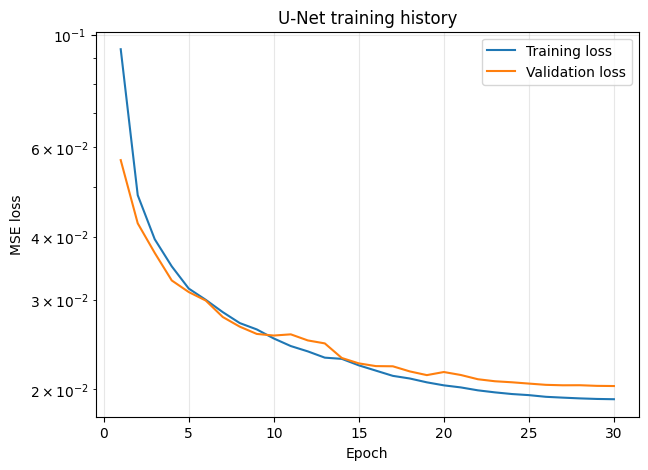

In [27]:
epochs = np.arange(
    1,
    len(train_losses) + 1,
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    val_losses,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("U-Net training history")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [28]:
unet.load_state_dict(best_model_state)

unet.eval()

print("Best U-Net restored.")

Best U-Net restored.


## 5. One-step evaluation

We first evaluate individual transitions from unseen trajectories. Predictions and targets are converted back to physical units before computing:

- **MSE**, the average squared error per grid point;
- **relative $L^2$ error**, $\lVert\widehat{\omega}-\omega\rVert_2/\lVert\omega\rVert_2$, the error relative to the target magnitude.

Spatial plots can reveal structured errors that a single scalar metric hides.

In [29]:
@torch.no_grad()
def evaluate_one_step(
    model,
    loader,
    mean,
    std,
    device,
):
    model.eval()

    mse_values = []
    rel_l2_values = []

    for x, y in loader:

        x = x.to(device).float()
        y = y.to(device).float()

        # Prediction in normalized space
        pred = model(x)

        # Convert back to physical scale
        pred_phys = pred * std + mean
        y_phys = y * std + mean

        # MSE per sample
        mse = (
            (pred_phys - y_phys)
            .pow(2)
            .flatten(1)
            .mean(dim=1)
        )

        # Relative L2 per sample
        diff_norm = torch.linalg.vector_norm(
            (pred_phys - y_phys).flatten(1),
            dim=1,
        )

        target_norm = torch.linalg.vector_norm(
            y_phys.flatten(1),
            dim=1,
        )

        rel_l2 = diff_norm / (
            target_norm + 1e-8
        )

        mse_values.append(
            mse.cpu()
        )

        rel_l2_values.append(
            rel_l2.cpu()
        )

    mse_values = torch.cat(mse_values)
    rel_l2_values = torch.cat(
        rel_l2_values
    )

    return {
        "MSE": mse_values.mean().item(),
        "Relative L2": (
            rel_l2_values.mean().item()
        ),
    }

In [30]:
unet_test_results = evaluate_one_step(
    model=unet,
    loader=test_loader,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

print("U-Net one-step test results")
print("---------------------------")

for metric, value in unet_test_results.items():
    print(
        f"{metric:12s}: {value:.6e}"
    )

U-Net one-step test results
---------------------------
MSE         : 2.643262e-02
Relative L2 : 1.354307e-01


In [31]:
@torch.no_grad()
def plot_one_step_prediction(
    model,
    dataset,
    sample_idx,
    mean,
    std,
    device,
):

    model.eval()

    x, y = dataset[sample_idx]

    x_batch = (
        x.unsqueeze(0)
        .to(device).float()
    )

    pred = model(x_batch)[0].cpu()

    # Convert to physical units
    x_phys = (
        x * std + mean
    ).squeeze().numpy()

    y_phys = (
        y * std + mean
    ).squeeze().numpy()

    pred_phys = (
        pred * std + mean
    ).squeeze().numpy()

    error = np.abs(
        pred_phys - y_phys
    )

    vmin = min(
        x_phys.min(),
        y_phys.min(),
        pred_phys.min(),
    )

    vmax = max(
        x_phys.max(),
        y_phys.max(),
        pred_phys.max(),
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4),
    )

    im = axes[0].imshow(
        x_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[0].set_title(
        r"Input $\omega_t$"
    )

    axes[1].imshow(
        y_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[1].set_title(
        r"True $\omega_{t+1}$"
    )

    axes[2].imshow(
        pred_phys,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[2].set_title(
        r"Predicted $\hat{\omega}_{t+1}$"
    )

    err_im = axes[3].imshow(
        error,
        origin="lower",
    )

    axes[3].set_title(
        "Absolute error"
    )

    plt.colorbar(
        im,
        ax=axes[:3],
        shrink=0.8,
    )

    plt.colorbar(
        err_im,
        ax=axes[3],
        shrink=0.8,
    )

    plt.show()

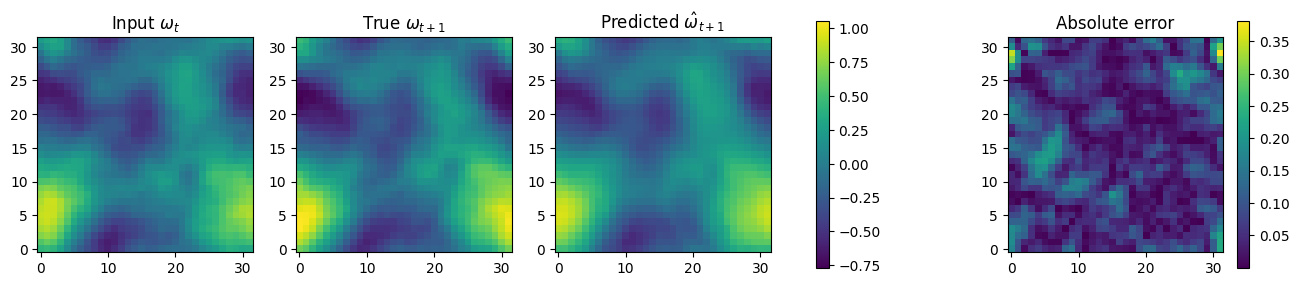

In [32]:
plot_one_step_prediction(
    model=unet,
    dataset=test_dataset,
    sample_idx=100,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

## 6. Multi-step prediction

One-step accuracy does not fully describe a dynamical surrogate. We compare two multi-step modes:

- **Teacher forcing:** every prediction receives the true current state, isolating one-step approximation error.
- **Autoregressive rollout:** every prediction becomes the next input, testing stability and accumulated distribution shift.

A model can perform well under teacher forcing yet drift autoregressively because it was trained on true states but encounters its own imperfect predictions at inference time.

In [33]:
def get_trajectory(
    trajectory_idx,
    initial_vorticity,
    vorticity,
    spatial_stride=1,
):
    """
    Returns a complete trajectory

        omega_0, ..., omega_20

    Shape:
        [21, H, W]
    """

    omega0 = initial_vorticity[
        trajectory_idx,
        ::spatial_stride,
        ::spatial_stride,
    ]

    future = vorticity[
        trajectory_idx,
        ::spatial_stride,
        ::spatial_stride,
        :,
    ]

    # future currently:
    # [H, W, 20]
    #
    # convert to:
    # [20, H, W]

    future = np.moveaxis(
        future,
        -1,
        0,
    )

    trajectory = np.concatenate(
        [
            omega0[None, ...],
            future,
        ],
        axis=0,
    )

    return trajectory.astype(
        np.float32
    )

In [81]:
@torch.no_grad()
def rollout_model(
    model,
    initial_state,
    n_steps,
    mean,
    std,
    device,
):
    """
    Generate an autoregressive rollout from one initial state.

    Args:
        model: Trained one-step prediction model.
        initial_state: Array with shape [H, W] in physical units.
        n_steps: Number of future states to predict.
        mean: Training-set mean used for normalization.
        std: Training-set standard deviation used for normalization.
        device: Device on which the model runs.

    Returns:
        A NumPy array in physical units with shape
        [n_steps + 1, H, W]. Element 0 must equal initial_state, and
        element t + 1 must contain the prediction produced at rollout step t.

    Notes:
        Normalize the initial state before the first model call. The model
        predicts normalized states, so denormalize each prediction before
        storing it. Keep the normalized prediction as the input to the next
        step; do not replace it with a true state.
    """
    model.eval()
    current_step = torch.tensor(initial_state / std - mean, device=device).float().unsqueeze(0).unsqueeze(0)
    result = np.zeros(shape=[n_steps + 1, initial_state.shape[0], initial_state.shape[1]])
    result[0] = initial_state
    for step in range(n_steps):
        next_step = model(current_step)
        result[step+1] = next_step.cpu().squeeze().squeeze().numpy() * std + mean
        current_step = next_step
    return result


In [82]:
trajectory = get_trajectory(
    trajectory_idx=test_indices[0],
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

print(trajectory.shape)

(21, 32, 32)


In [93]:
@torch.no_grad()
def rollout_model_teacher_forcing(
    model,
    true_trajectory,
    mean,
    std,
    device,
):
    """
    Generate one-step predictions using the true state at every time step.

    Args:
        model: Trained one-step prediction model.
        true_trajectory: Array with shape [T, H, W] in physical units.
        mean: Training-set mean used for normalization.
        std: Training-set standard deviation used for normalization.
        device: Device on which the model runs.

    Returns:
        A NumPy array in physical units with shape [T, H, W]. Element 0
        must equal true_trajectory[0]. For t = 0, ..., T - 2, element
        t + 1 must be the prediction obtained from true_trajectory[t].

    Notes:
        Normalize each true input state before applying the model and
        denormalize every prediction before storing it. Predictions are never
        fed back into the model in teacher-forcing mode.
    """
    model.eval()

    current_step = torch.tensor(true_trajectory[0] / std - mean, device=device).float().unsqueeze(0).unsqueeze(0)
    result = np.zeros(shape=true_trajectory.shape)
    result[0] = true_trajectory[0]
    for i, step in enumerate(true_trajectory[0:20]):
        step_tensor = torch.tensor(step / std - mean, device=device).float().unsqueeze(0).unsqueeze(0)
        next_step = model(step_tensor)
        result[i+1] = next_step.cpu().numpy().squeeze(0).squeeze(0) * std + mean
        current_step = next_step
    return result

In [94]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=unet,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

teacher_forced_predictions = rollout_model_teacher_forcing(
        model=unet,
        true_trajectory=true_trajectory,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )


print(
    "True trajectory:",
    true_trajectory.shape,
)

print(
    "Predicted trajectory:",
    pred_trajectory.shape,
)


print(
    "Predicted teacher forcing trajectory:",
    teacher_forced_predictions.shape,
)

True trajectory: (21, 32, 32)
Predicted trajectory: (21, 32, 32)
Predicted teacher forcing trajectory: (21, 32, 32)


In [95]:
def trajectory_relative_l2(
    prediction,
    target,
    eps=1e-8,
):
    """
    prediction, target:
        [T, H, W]

    Returns:
        [T]
    """

    diff = prediction - target

    numerator = np.sqrt(
        np.sum(
            diff**2,
            axis=(1, 2),
        )
    )

    denominator = np.sqrt(
        np.sum(
            target**2,
            axis=(1, 2),
        )
    )

    return numerator / (
        denominator + eps
    )

In [96]:
rollout_error = trajectory_relative_l2(
    pred_trajectory,
    true_trajectory,
)

print(rollout_error.shape)

teacher_forcing_error = trajectory_relative_l2(
    teacher_forced_predictions,
    true_trajectory,
)

print(teacher_forcing_error.shape)

(21,)
(21,)


In [97]:
@torch.no_grad()
def evaluate_rollouts(
    model,
    trajectory_indices,
    initial_vorticity,
    vorticity,
    spatial_stride,
    mean,
    std,
    device,
    n_steps=20,
):
    all_errors = []
    all_errors_teacher_forcing = []

    # Retain an error curve for every trajectory before averaging.
    for trajectory_idx in trajectory_indices:

        true_trajectory = get_trajectory(
            trajectory_idx,
            initial_vorticity,
            vorticity,
            spatial_stride,
        )

        pred_trajectory = rollout_model(
            model=model,
            initial_state=true_trajectory[0],
            n_steps=n_steps,
            mean=mean,
            std=std,
            device=device,
        )

        pred_trajectory_teacher_forcing = rollout_model_teacher_forcing(
            model=model,
            true_trajectory=true_trajectory[:n_steps + 1],
            mean=mean,
            std=std,
            device=device,
        )

        errors = trajectory_relative_l2(
            pred_trajectory,
            true_trajectory[
                :n_steps + 1
            ],
        )


        errors_teacher_forcing = trajectory_relative_l2(
            pred_trajectory_teacher_forcing,
            true_trajectory[:n_steps + 1],
        )

        all_errors.append(errors)
        all_errors_teacher_forcing.append(errors_teacher_forcing)

    all_errors = np.stack(
        all_errors,
        axis=0,
    )

    all_errors_teacher_forcing = np.stack(
            all_errors_teacher_forcing,
            axis=0,
        )

    return all_errors, all_errors_teacher_forcing

In [98]:
unet_rollout_errors, unet_teacher_forcing_errors = evaluate_rollouts(
    model=unet,
    trajectory_indices=test_indices,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
    mean=omega_mean,
    std=omega_std,
    device=device,
    n_steps=20,
)

print(
    unet_rollout_errors.shape
)

print(
    unet_teacher_forcing_errors.shape
)

(200, 21)
(200, 21)


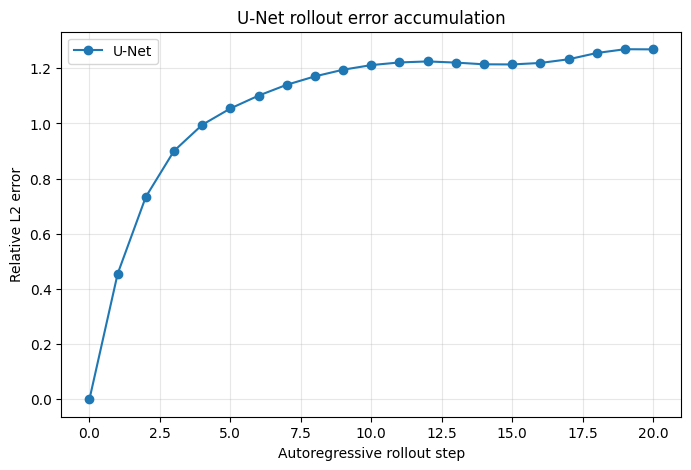

In [99]:
mean_rollout_error = (
    unet_rollout_errors.mean(axis=0)
)

std_rollout_error = (
    unet_rollout_errors.std(axis=0)
)

steps = np.arange(
    len(mean_rollout_error)
)

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    mean_rollout_error,
    marker="o",
    label="U-Net",
)

# plt.fill_between(
#     steps,
#     mean_rollout_error
#     - std_rollout_error,
#     mean_rollout_error
#     + std_rollout_error,
#     alpha=0.2,
# )

plt.xlabel("Autoregressive rollout step")
plt.ylabel("Relative L2 error")

plt.title(
    "U-Net rollout error accumulation"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [100]:
def plot_rollout(
    true_trajectory,
    pred_trajectory,
    times=(0, 5, 10, 15, 20),
):

    n = len(times)

    fig, axes = plt.subplots(
        3,
        n,
        figsize=(3 * n, 8),
    )

    vmin = min(
        true_trajectory.min(),
        pred_trajectory.min(),
    )

    vmax = max(
        true_trajectory.max(),
        pred_trajectory.max(),
    )

    for j, t in enumerate(times):

        # -------------------------
        # Ground truth
        # -------------------------

        axes[0, j].imshow(
            true_trajectory[t],
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        axes[0, j].set_title(
            f"True t={t}"
        )

        # -------------------------
        # Prediction
        # -------------------------

        axes[1, j].imshow(
            pred_trajectory[t],
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        axes[1, j].set_title(
            f"Prediction t={t}"
        )

        # -------------------------
        # Error
        # -------------------------

        error = np.abs(
            pred_trajectory[t]
            - true_trajectory[t]
        )

        axes[2, j].imshow(
            error,
            origin="lower",
        )

        axes[2, j].set_title(
            f"|Error| t={t}"
        )

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    axes[0, 0].set_ylabel(
        "Ground truth"
    )

    axes[1, 0].set_ylabel(
        "U-Net"
    )

    axes[2, 0].set_ylabel(
        "Absolute error"
    )

    plt.tight_layout()
    plt.show()

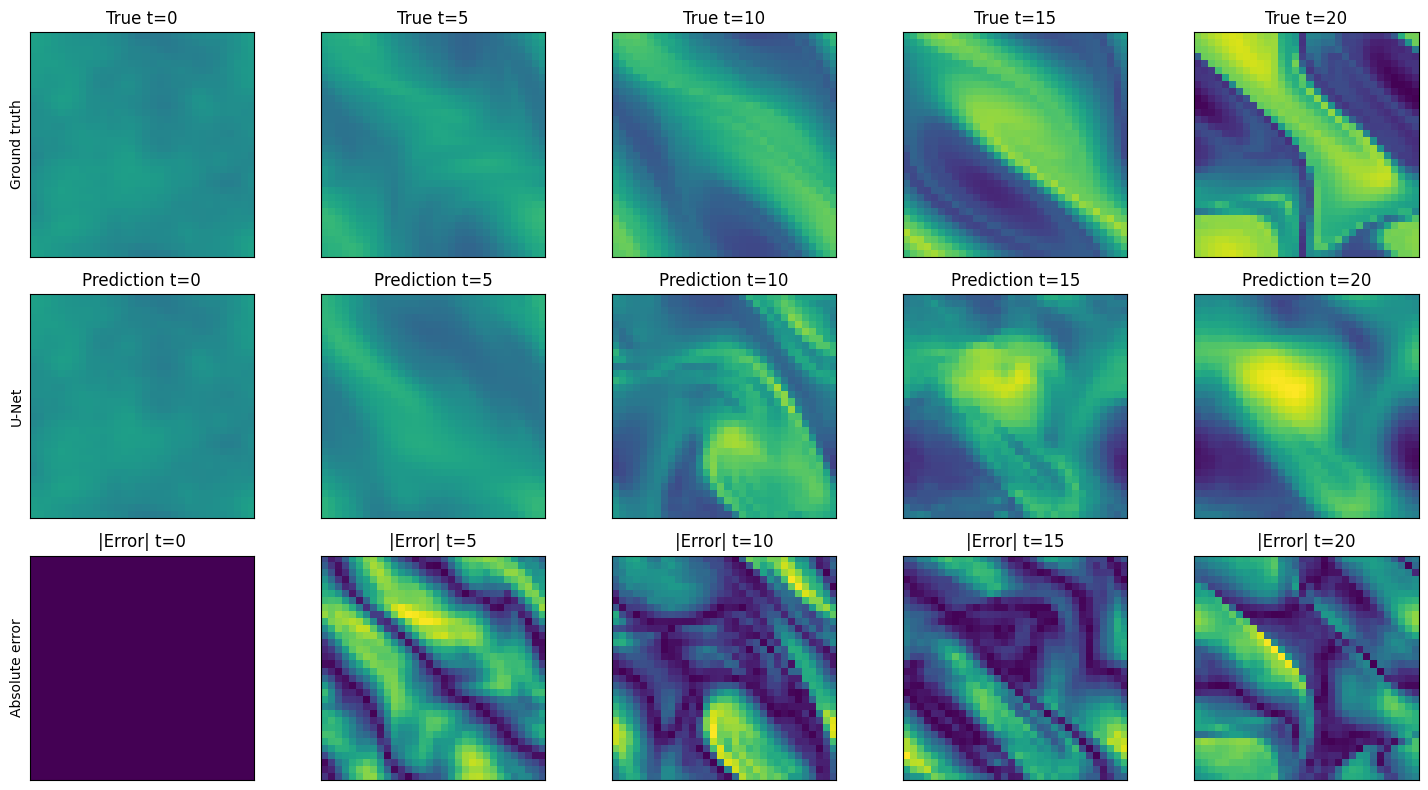

In [101]:
plot_rollout(
    true_trajectory,
    pred_trajectory,
)

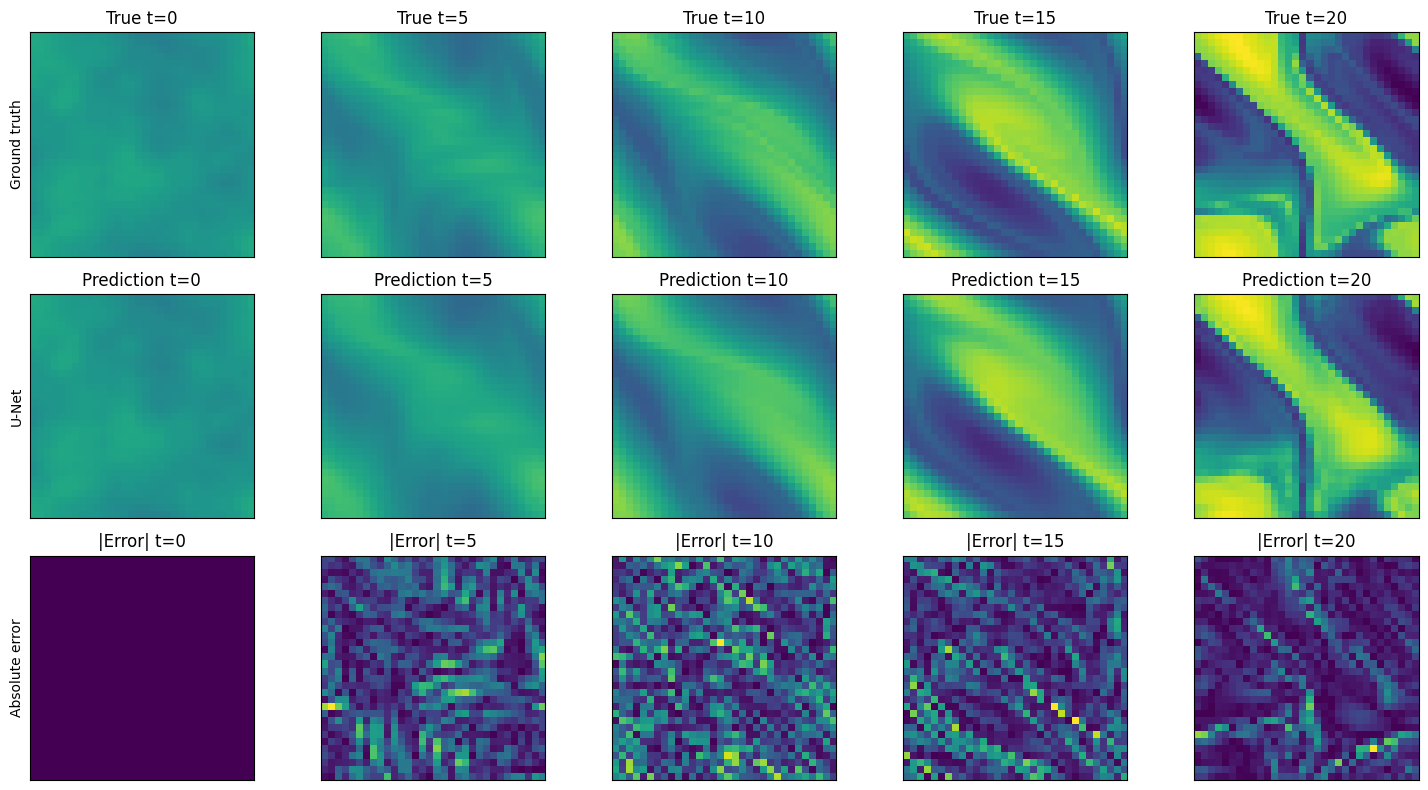

In [102]:
plot_rollout(
    true_trajectory,
    teacher_forced_predictions,
)

## 7. A spatial Transformer

As an alternative to convolution, every grid point becomes a token. At the downsampled resolution, one field produces $32\times32=1024$ tokens. Global self-attention allows every location to interact directly with every other location.

A vorticity value alone does not identify a token's position, so we append periodic coordinates

$$[\sin(2\pi x),\cos(2\pi x),\sin(2\pi y),\cos(2\pi y)].$$

These features respect the topology of the periodic domain. Like the U-Net, the Transformer predicts a residual update.

> Global attention has quadratic cost in the number of tokens. Doubling resolution in both directions creates four times as many tokens and roughly sixteen times as many pairwise attention scores.

In [103]:
def make_periodic_position_features(H, W):
    """
    Create periodic positional features for a H x W grid.

    Returns:
        pos: [H*W, 4]

    Features:
        sin(2*pi*x), cos(2*pi*x),
        sin(2*pi*y), cos(2*pi*y)
    """

    # Map indices to [0, 1); sine and cosine join both ends periodically.
    x = torch.arange(H, dtype=torch.float32) / H
    y = torch.arange(W, dtype=torch.float32) / W

    xx, yy = torch.meshgrid(
        x,
        y,
        indexing="ij",
    )

    pos = torch.stack(
        [
            torch.sin(2 * torch.pi * xx),
            torch.cos(2 * torch.pi * xx),
            torch.sin(2 * torch.pi * yy),
            torch.cos(2 * torch.pi * yy),
        ],
        dim=-1,
    )

    # [H, W, 4] -> [H*W, 4]
    pos = pos.reshape(H * W, 4)

    return pos

In [104]:
class SpatialTransformer(nn.Module):

    def __init__(
        self,
        H,
        W,
        d_model=64,
        n_heads=4,
        n_layers=2,
        dim_feedforward=256,
        dropout=0.0,
        residual_prediction=True,
    ):
        super().__init__()

        self.H = H
        self.W = W
        self.N = H * W

        self.residual_prediction = residual_prediction

        # -----------------------------------
        # Fixed periodic positional features
        # -----------------------------------

        pos = make_periodic_position_features(
            H,
            W,
        )

        self.register_buffer(
            "pos_features",
            pos,
        )

        # omega + 4 positional features
        self.input_projection = nn.Linear(
            5,
            d_model,
        )

        # -----------------------------------
        # Transformer encoder
        # -----------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(
            d_model
        )

        # -----------------------------------
        # Output: one scalar per grid point
        # -----------------------------------

        self.output_projection = nn.Linear(
            d_model,
            1,
        )


    def forward(self, x):
        """
        x:
            [B, 1, H, W]

        output:
            [B, 1, H, W]
        """

        B = x.shape[0]

        input_state = x

        # -----------------------------------
        # Convert grid to tokens
        # -----------------------------------

        # [B, 1, H, W]
        # ->
        # [B, H, W]
        x = x[:, 0]

        # ->
        # [B, N, 1]
        x = x.reshape(
            B,
            self.N,
            1,
        )

        # -----------------------------------
        # Add positional information
        # -----------------------------------

        # [N, 4]
        # ->
        # [B, N, 4]
        pos = self.pos_features.unsqueeze(0).expand(
            B,
            -1,
            -1,
        )

        # [B, N, 5]
        x = torch.cat(
            [x, pos],
            dim=-1,
        )

        # -----------------------------------
        # Token embedding
        # -----------------------------------

        # [B, N, 5]
        # ->
        # [B, N, d_model]
        x = self.input_projection(x)

        # -----------------------------------
        # Global self-attention
        # -----------------------------------

        x = self.transformer(x)

        x = self.norm(x)

        # -----------------------------------
        # Predict delta omega
        # -----------------------------------

        # [B, N, d_model]
        # ->
        # [B, N, 1]
        delta = self.output_projection(x)

        # ->
        # [B, 1, H, W]
        delta = delta.reshape(
            B,
            1,
            self.H,
            self.W,
        )

        if self.residual_prediction:
            return input_state + delta

        return delta

In [105]:
# stride = 1 -> 64 x 64
# stride = 2 -> 32 x 32

H = 64 // SPATIAL_STRIDE
W = 64 // SPATIAL_STRIDE

transformer = SpatialTransformer(
    H=H,
    W=W,
    d_model=64,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.0,
    residual_prediction=True,
).to(device)

/tmp/ipykernel_3457/3077198302.py:56: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [106]:
n_params = sum(
    p.numel()
    for p in transformer.parameters()
    if p.requires_grad
)

print(
    f"Transformer parameters: "
    f"{n_params:,}"
)

Transformer parameters: 100,545


### Training the Transformer

We reuse the same data, loss, optimizer family, and learning-rate schedule. Conclusions about architecture quality nevertheless require comparable training budgets and the same validation protocol.

In [107]:
transformer_criterion = nn.MSELoss()

transformer_optimizer = torch.optim.AdamW(
    transformer.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

N_TRANSFORMER_EPOCHS = 30

transformer_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        transformer_optimizer,
        T_max=N_TRANSFORMER_EPOCHS,
    )
)

In [108]:
transformer_train_losses = []
transformer_val_losses = []

best_transformer_val_loss = float("inf")
best_transformer_state = None

start_time = time.time()

for epoch in range(
    1,
    N_TRANSFORMER_EPOCHS + 1,
):

    train_loss = train_one_epoch(
        model=transformer,
        loader=train_loader,
        optimizer=transformer_optimizer,
        criterion=transformer_criterion,
        device=device,
    )

    val_loss = evaluate_loss(
        model=transformer,
        loader=val_loader,
        criterion=transformer_criterion,
        device=device,
    )

    transformer_train_losses.append(
        train_loss
    )

    transformer_val_losses.append(
        val_loss
    )

    if val_loss < best_transformer_val_loss:

        best_transformer_val_loss = val_loss

        best_transformer_state = copy.deepcopy(
            transformer.state_dict()
        )

    transformer_scheduler.step()

    print(
        f"Epoch "
        f"{epoch:3d}/"
        f"{N_TRANSFORMER_EPOCHS} | "
        f"Train: {train_loss:.6e} | "
        f"Val: {val_loss:.6e} | "
        f"LR: "
        f"{transformer_optimizer.param_groups[0]['lr']:.2e}"
    )


elapsed = time.time() - start_time

print()
print(
    f"Training time: "
    f"{elapsed / 60:.1f} minutes"
)

print(
    f"Best validation loss: "
    f"{best_transformer_val_loss:.6e}"
)

KeyboardInterrupt: 

In [ ]:
transformer.load_state_dict(
    best_transformer_state
)

transformer.eval()

print(
    "Best Transformer restored."
)

In [ ]:
epochs = np.arange(
    1,
    len(transformer_train_losses) + 1,
)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    transformer_train_losses,
    label="Training loss",
)

plt.plot(
    epochs,
    transformer_val_losses,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Transformer training history")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Evaluating the Transformer

The Transformer uses the same one-step and rollout utilities as the U-Net. Shared evaluation code prevents preprocessing or metric differences from being mistaken for model differences.

In [ ]:
transformer_test_results = (
    evaluate_one_step(
        model=transformer,
        loader=test_loader,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )
)

print(
    "Transformer one-step test results"
)

print(
    "---------------------------------"
)

for metric, value in (
    transformer_test_results.items()
):
    print(
        f"{metric:12s}: "
        f"{value:.6e}"
    )

In [ ]:
plot_one_step_prediction(
    model=transformer,
    dataset=test_dataset,
    sample_idx=0,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

In [ ]:
(transformer_rollout_errors, transformer_teacher_forcing_errors) = (
    evaluate_rollouts(
        model=transformer,
        trajectory_indices=test_indices,
        initial_vorticity=initial_vorticity,
        vorticity=vorticity,
        spatial_stride=SPATIAL_STRIDE,
        mean=omega_mean,
        std=omega_std,
        device=device,
        n_steps=20,
    )
)

print("Autoregressive errors:", transformer_rollout_errors.shape)
print("Teacher-forced errors:", transformer_teacher_forcing_errors.shape)

In [ ]:
trajectory_idx = test_indices[1]

true_trajectory = get_trajectory(
    trajectory_idx=trajectory_idx,
    initial_vorticity=initial_vorticity,
    vorticity=vorticity,
    spatial_stride=SPATIAL_STRIDE,
)

pred_trajectory = rollout_model(
    model=transformer,
    initial_state=true_trajectory[0],
    n_steps=20,
    mean=omega_mean,
    std=omega_std,
    device=device,
)

teacher_forced_predictions = rollout_model_teacher_forcing(
        model=transformer,
        true_trajectory=true_trajectory,
        mean=omega_mean,
        std=omega_std,
        device=device,
    )


print(
    "True trajectory:",
    true_trajectory.shape,
)

print(
    "Predicted trajectory:",
    pred_trajectory.shape,
)


print(
    "Predicted teacher forcing trajectory:",
    teacher_forced_predictions.shape,
)

In [ ]:
plot_rollout(
    true_trajectory,
    pred_trajectory,
)

In [ ]:
plot_rollout(
    true_trajectory,
    teacher_forced_predictions,
)